In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

import networkx as nx
import matplotlib.pyplot as plt
import rdkit
from rdkit import Chem
from rdkit.Chem import Draw

from tokengt_paper_repo.tokengt_paper import TokenGTPaperGraphRegression
from tokengt_paper_experiments.pcqm4m_dataset import PCQM4MDataset
from models.add_smarts_instances import get_qm9_smarts_patterns

In [2]:
def load_model_and_checkpoint(checkpoint_path, config):
    """Load the model from checkpoint"""
    smarts_patterns = get_qm9_smarts_patterns()
    n_substructures = len(smarts_patterns)

    data_module = PCQM4MDataset(
        batch_size=1,
        num_workers=config["num_workers"],
        d_p=config["D_P"],
        node_id_mode=config["node_id_mode"],
        smarts_patterns=smarts_patterns,
        embed_smarts=config["embed_smarts"],
        dataset_fraction=0.01,
    )

    data_module.setup()
    
    node_dim = 9 + n_substructures if config["embed_smarts"] else 9
    num_atoms = PCQM4MDataset.SINGLE_EMB_OFFSET * node_dim
    num_edges = 4 * PCQM4MDataset.SINGLE_EMB_OFFSET
    
    if config["architecture"] == "TokenGT_Paper":
        model = TokenGTPaperGraphRegression(
            num_atoms=num_atoms,
            num_edges=num_edges,
            d_p=config["D_P"],
            d=config["d"],
            num_heads=config["num_heads"],
            num_encoder_layers=config["num_encoder_layers"],
            node_id_mode=config["node_id_mode"],
            dropout=config["dropout"],
            lr=config["lr"],
            batch_size=config["batch_size"],
            weight_decay=config["weight_decay"],
            return_attention=True,
            use_interaction_bias=config["use_interaction_bias"],
        )
    elif config["architecture"] == "TokenGT_Paper_Sum":
        model = TokenGTPaperGraphRegression(
            num_atoms=num_atoms,
            num_edges=num_edges,
            d_p=config["D_P"],
            d=config["d"],
            num_heads=config["num_heads"],
            num_encoder_layers=config["num_encoder_layers"],
            node_id_mode=config["node_id_mode"],
            dropout=config["dropout"],
            lr=config["lr"],
            batch_size=config["batch_size"],
            weight_decay=config["weight_decay"],
            substructure_mode="sum",
            n_substructures=n_substructures,
            return_attention=True,
            use_interaction_bias=config["use_interaction_bias"],
        )
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    model.load_state_dict(checkpoint['state_dict'])
    model.eval()
    
    return model, data_module

config = {
    "architecture": "TokenGT_Paper_Sum",
    "dataset": "PCQM4M",
    "embed_smarts": False,
    "node_id_mode": "orf",
    "D_P": 16,
    "num_heads": 16,
    "d": 128,
    "num_encoder_layers": 4,
    "epochs": 100,
    "batch_size": 512,
    "lr": 0.005,
    "num_workers": 8,
    "weight_decay": 0.01,
    "dropout": 0.1,
    "checkpointing": False,
    "seed": 1,
    "use_interaction_bias": False
}

checkpoint_path = "tokengt_experiments/model_analysis/tgt_s_orf-val_loss=0.1832.ckpt"
# checkpoint_path = "tokengt_experiments/model_analysis/tgt_s_lap-val_loss=0.1431.ckpt"
tgts_model, data_module = load_model_and_checkpoint(checkpoint_path, config)

# checkpoint_path = "tokengt_experiments/model_analysis/tgt_orf-val_loss=0.1914.ckpt"
checkpoint_path = "tokengt_experiments/model_analysis/tgt_orf_emb-val_loss=0.1722.ckpt"
config["embed_smarts"] = True
# checkpoint_path = "tokengt_experiments/model_analysis/tgt_lap-val_loss=0.1382.ckpt"
config["architecture"] = "TokenGT_Paper"
tgt_model, data_module = load_model_and_checkpoint(checkpoint_path, config)
    

Using 1.0% of dataset: train=10, val=1000, test=147037
Using 1.0% of dataset: train=10, val=1000, test=147037


In [3]:
samples = []
for batch in data_module.val_dataloader():
    samples.append(batch)
    if len(samples) > 1000:
        break

print(samples)

[DataBatch(x=[17, 19], edge_index=[2, 36], edge_attr=[36, 3], y=[1], smiles=[1], substructure_instances=[0, 8], n_substructure_instances=[1], node_data=[17, 19], edge_data=[36, 3], in_degree=[17], out_degree=[17], lap_eigvec=[17, 16], batch=[17], ptr=[2]), DataBatch(x=[10, 19], edge_index=[2, 22], edge_attr=[22, 3], y=[1], smiles=[1], substructure_instances=[0, 8], n_substructure_instances=[1], node_data=[10, 19], edge_data=[22, 3], in_degree=[10], out_degree=[10], lap_eigvec=[10, 16], batch=[10], ptr=[2]), DataBatch(x=[17, 19], edge_index=[2, 34], edge_attr=[34, 3], y=[1], smiles=[1], substructure_instances=[7, 8], n_substructure_instances=[1], node_data=[17, 19], edge_data=[34, 3], in_degree=[17], out_degree=[17], lap_eigvec=[17, 16], batch=[17], ptr=[2]), DataBatch(x=[16, 19], edge_index=[2, 34], edge_attr=[34, 3], y=[1], smiles=[1], substructure_instances=[6, 8], n_substructure_instances=[1], node_data=[16, 19], edge_data=[34, 3], in_degree=[16], out_degree=[16], lap_eigvec=[16, 16

In [43]:
sample_idx = 4
sample = samples[sample_idx]

n_nodes = sample.node_data.shape[0]
n_edges = sample.edge_data.shape[0]
n_substructures = sample.substructure_instances.shape[0]
substructure_start = 1 + n_nodes + n_edges

print(f"Number of nodes: {n_nodes}")
print(f"Number of edges: {n_edges}")
print(f"Number of substructures: {n_substructures}")
print(f"Substructure instances: {sample.substructure_instances}")
print(f"Node data: {sample.node_data}")
print(f"Smiles: {sample.smiles[0]}")

tgts_pred, tgts_maps = tgts_model(sample)
tgt_pred, tgt_maps = tgt_model(sample)

tgts_attn = [tgts_maps["maps"][i].detach().numpy() for i in range(len(tgts_maps["maps"]))]
tgts_attn = np.array(tgts_attn).squeeze()

tgt_attn = [tgt_maps["maps"][i].detach().numpy() for i in range(len(tgt_maps["maps"]))]
tgt_attn = np.array(tgt_attn).squeeze()

G = nx.Graph()
G.add_edges_from(sample.edge_index.T.tolist())
nx.draw(G, with_labels=True)
plt.show()

mol = Chem.MolFromSmiles(sample.smiles[0])
img = Draw.MolToImage(mol, size=(300, 300))
img

Number of nodes: 16
Number of edges: 34
Number of substructures: 4
Substructure instances: tensor([[ 3,  4,  5,  6,  7,  8,  9, -1],
        [ 6, 12, 11, -1, -1, -1, -1, -1],
        [ 7, 11, 12, 13, -1, -1, -1, -1],
        [ 8,  2,  3, -1, -1, -1, -1, -1]])
Node data: tensor([[   6,  512, 1025, 1541, 2048, 2560, 3072, 3584, 4096, 4608, 5120, 5632,
         6144, 6656, 7168, 7680, 8192, 8704, 9216],
        [   5,  512, 1026, 1541, 2048, 2560, 3072, 3584, 4096, 4608, 5120, 5632,
         6144, 6656, 7168, 7680, 8192, 8704, 9216],
        [   5,  512, 1027, 1541, 2048, 2560, 3073, 3584, 4097, 4608, 5120, 5632,
         6144, 6656, 7168, 7680, 8192, 8705, 9216],
        [   5,  512, 1027, 1541, 2048, 2560, 3073, 3584, 4097, 4608, 5120, 5632,
         6144, 6656, 7168, 7680, 8192, 8705, 9216],
        [   5,  512, 1027, 1541, 2048, 2560, 3073, 3585, 4097, 4608, 5120, 5632,
         6145, 6656, 7168, 7680, 8192, 8704, 9216],
        [   5,  512, 1027, 1541, 2049, 2560, 3073, 3585, 4097, 4

IndexError: index out of range in self

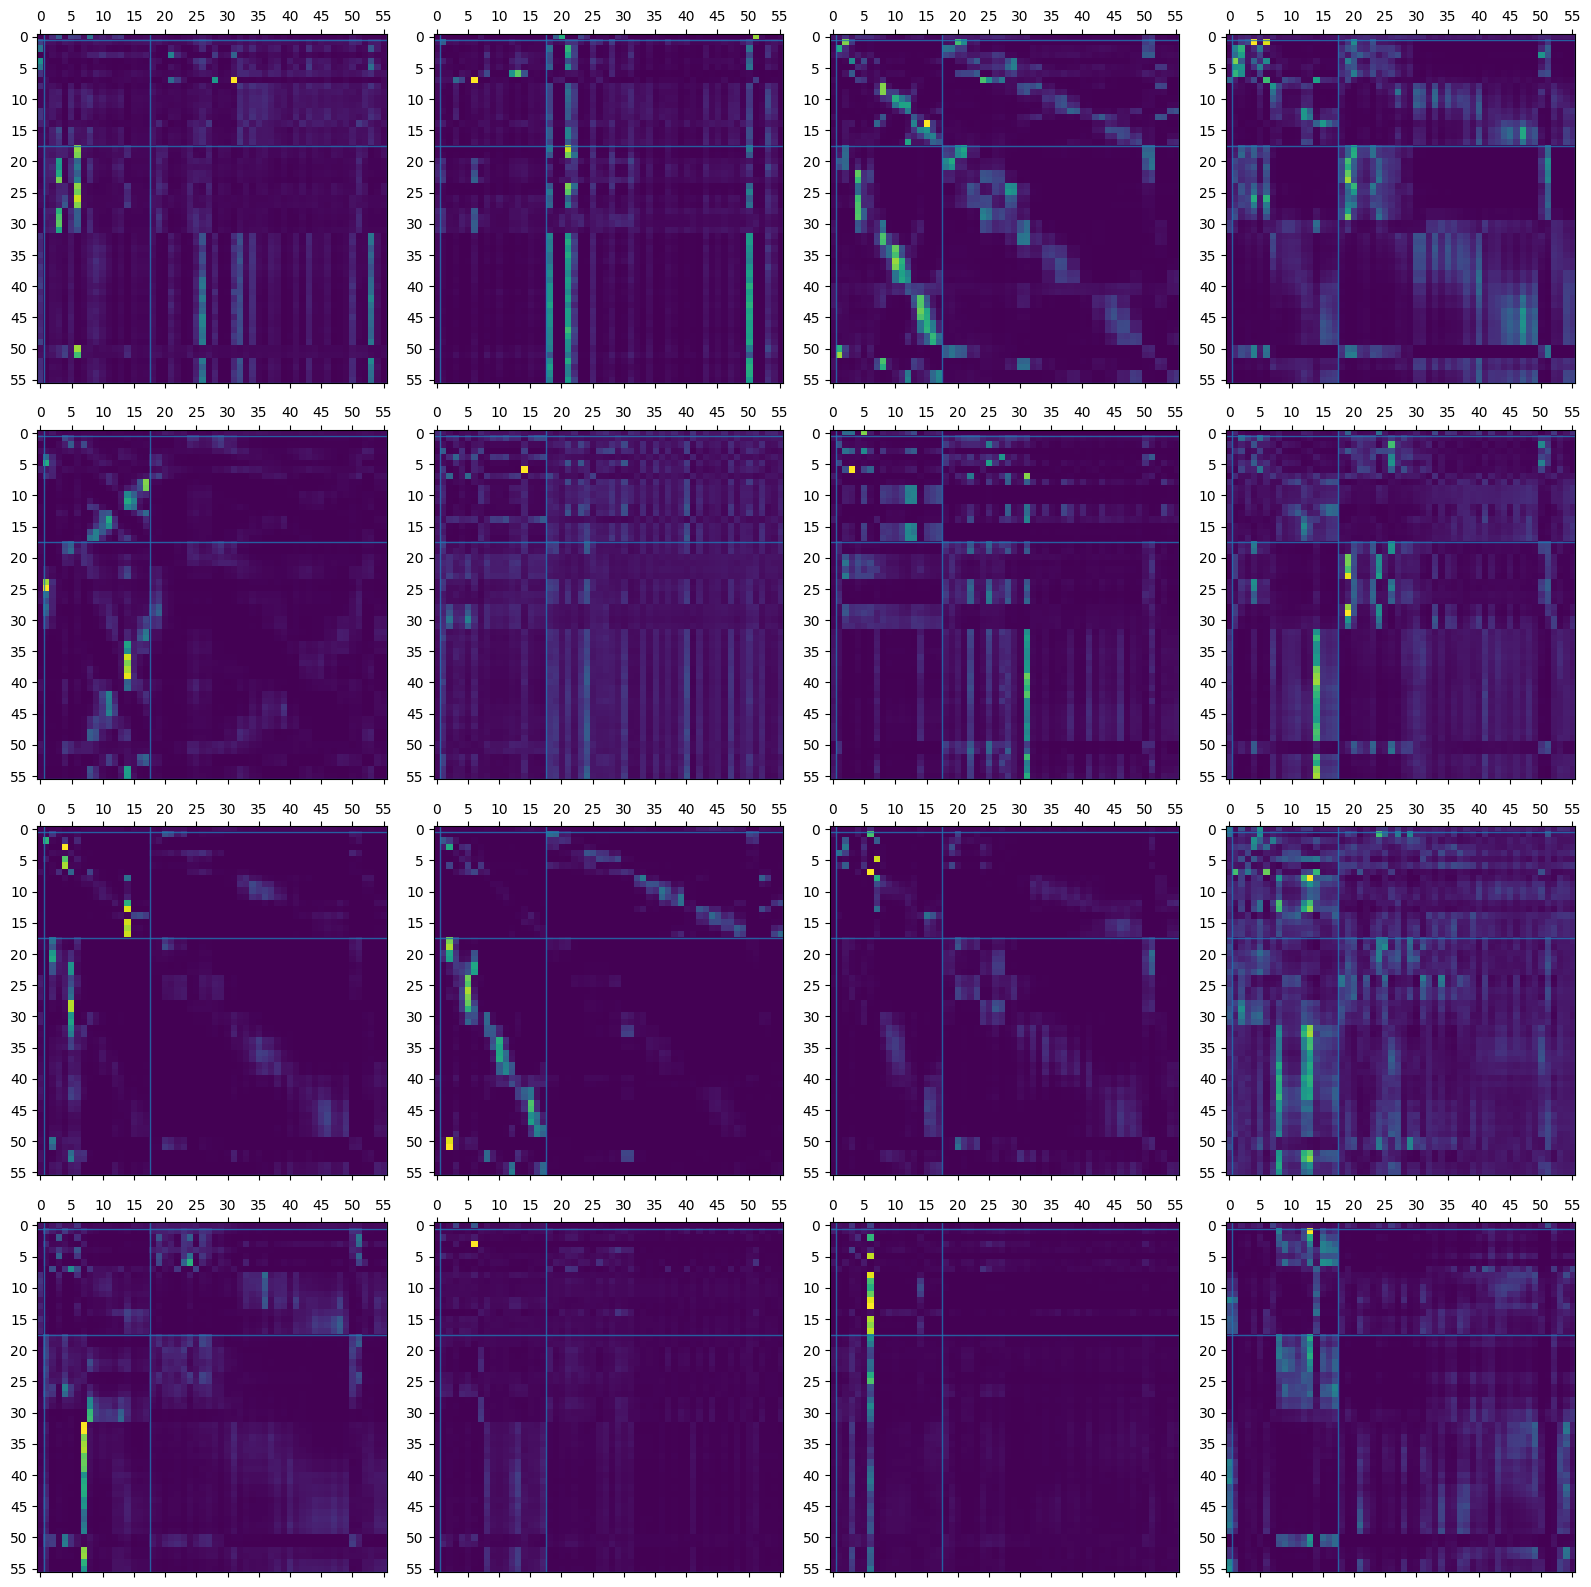

In [41]:
import matplotlib.pyplot as plt

def plot_attention_with_token_bars_from_sample(maps, sample, layer_idx=0):

    node_start = 1 # graph token
    edge_start = node_start + n_nodes
    substructure_start = edge_start + n_edges
    
    num_heads = len(maps["maps"][0])

    fig, axs = plt.subplots(num_heads // 4, 4, figsize=(16, 16))
    for head in range(num_heads):
        ax = axs[head // 4, head % 4]
        
        attn_matrix = maps["maps"][layer_idx][head][0].detach().numpy()
        im = ax.matshow(attn_matrix, cmap="viridis")

        ax.set_xticks(np.arange(0, attn_matrix.shape[1], 5))
        ax.set_yticks(np.arange(0, attn_matrix.shape[0], 5))
        
        ax.axvline(x=node_start-0.5, linewidth=1, alpha=0.8)
        ax.axhline(y=node_start-0.5, linewidth=1, alpha=0.8)
        
        ax.axvline(x=edge_start-0.5, linewidth=1, alpha=0.8)
        ax.axhline(y=edge_start-0.5, linewidth=1, alpha=0.8)
        
        ax.axvline(x=substructure_start-0.5, linewidth=1, alpha=0.8)
        ax.axhline(y=substructure_start-0.5, linewidth=1, alpha=0.8)
    
    plt.tight_layout()
    
    return fig

fig = plot_attention_with_token_bars_from_sample(tgts_maps, sample, layer_idx=0)
plt.show()
fig = plot_attention_with_token_bars_from_sample(tgt_maps, sample, layer_idx=0)
plt.show()

In [35]:
def get_row_normalized_attn(attn, row_start, row_end, col_start, col_end):
    attn = attn[:, :, :, col_start:col_end]
    attn = attn / attn.sum(axis=3, keepdims=True)
    return attn[:, :, row_start:row_end, :]

def get_attn_stats(attn):
    node_mean_attn = get_row_normalized_attn(attn, 1, substructure_start, 1, substructure_start).reshape(-1, substructure_start-1).mean(axis=0)
    constituent_node_set = np.unique(sample.substructure_instances[:, 1:][sample.substructure_instances[:, 1:] != -1])
    non_constituent_nodes = sorted(set(range(n_nodes)) - set(constituent_node_set))
    return node_mean_attn[constituent_node_set].mean(), node_mean_attn[non_constituent_nodes].mean()

def get_st_updated_attn(attn):
    node_mean_attn = get_row_normalized_attn(attn, 1, substructure_start, 1, attn.shape[3]).reshape(-1, attn.shape[3]-1).mean(axis=0)
    constituent_node_set = np.unique(sample.substructure_instances[:, 1:][sample.substructure_instances[:, 1:] != -1])
    non_constituent_nodes = sorted(set(range(n_nodes)) - set(constituent_node_set))
    token_mean_attn = get_row_normalized_attn(attn, 1, substructure_start, 1, attn.shape[3]).reshape(-1, attn.shape[3]-1).mean(axis=0)[n_nodes+n_edges:]
    st_by_node_attn = np.zeros(n_nodes)
    for i, subs in enumerate(sample.substructure_instances):
        safe_indices = subs[1:][subs[1:] != -1]
        st_by_node_attn[safe_indices] += token_mean_attn[i] / len(safe_indices)
    updated_attn = node_mean_attn[:n_nodes] + st_by_node_attn
    return updated_attn[constituent_node_set].mean(), updated_attn[non_constituent_nodes].mean()


tgts_consts = []
tgts_non_consts = []
tgt_consts = []
tgt_non_consts = []
tgts_updated_consts = []
tgts_updated_non_consts = []
for sample_idx in range(1000):
    sample = samples[sample_idx]

    n_nodes = sample.node_data.shape[0]
    n_edges = sample.edge_data.shape[0]
    n_substructures = sample.substructure_instances.shape[0]
    substructure_start = 1 + n_nodes + n_edges

    if n_substructures == 0:
        continue
    
    tgts_pred, tgts_maps = tgts_model(sample)
    tgt_pred, tgt_maps = tgt_model(sample)

    tgts_attn = [tgts_maps["maps"][i].detach().numpy() for i in range(len(tgts_maps["maps"]))]
    tgts_attn = np.array(tgts_attn).squeeze()

    tgt_attn = [tgt_maps["maps"][i].detach().numpy() for i in range(len(tgt_maps["maps"]))]
    tgt_attn = np.array(tgt_attn).squeeze()

    tgts_const, tgts_non_const = get_attn_stats(tgts_attn)
    tgt_const, tgt_non_const = get_attn_stats(tgt_attn)
    tgts_updated_const, tgts_updated_non_const = get_st_updated_attn(tgts_attn)

    tgts_consts.append(tgts_const)
    tgts_non_consts.append(tgts_non_const)
    tgt_consts.append(tgt_const)
    tgt_non_consts.append(tgt_non_const)
    tgts_updated_consts.append(tgts_updated_const)
    tgts_updated_non_consts.append(tgts_updated_non_const)

print(f"TGTS constituent node set mean attn: {np.mean(tgts_consts)}")
print(f"TGTS non constituent node set mean attn: {np.nanmean(tgts_non_consts)}")
print(f"TGTS updated constituent node set mean attn: {np.mean(tgts_updated_consts)}")
print(f"TGTS updated non constituent node set mean attn: {np.nanmean(tgts_updated_non_consts)}")
print("--------------------------------")
print(f"TGT constituent node set mean attn: {np.mean(tgt_consts)}")
print(f"TGT non constituent node set mean attn: {np.nanmean(tgt_non_consts)}")


/var/folders/k8/qybls4_s35z08vdl10p0fc780000gn/T/ipykernel_89365/2468366146.py:10: RuntimeWarning: Mean of empty slice.
  return node_mean_attn[constituent_node_set].mean(), node_mean_attn[non_constituent_nodes].mean()
/var/folders/k8/qybls4_s35z08vdl10p0fc780000gn/T/ipykernel_89365/2468366146.py:22: RuntimeWarning: Mean of empty slice.
  return updated_attn[constituent_node_set].mean(), updated_attn[non_constituent_nodes].mean()


TGTS constituent node set mean attn: 0.03093736618757248
TGTS non constituent node set mean attn: 0.03018040396273136
TGTS updated constituent node set mean attn: 0.04151272370126392
TGTS updated non constituent node set mean attn: 0.02796786640938578
--------------------------------
TGT constituent node set mean attn: 0.034593429416418076
TGT non constituent node set mean attn: 0.02973831258714199


In [4]:
def get_attn_stats(attn):
    node_attn = attn[:, :, 1:1+n_nodes, 1:1+n_nodes]
    node_attn = node_attn / node_attn.sum(axis=3, keepdims=True)
    node_mean_attn = node_attn.reshape(-1, n_nodes).sum(axis=0) / node_attn.shape[0] / node_attn.shape[1]
    constituent_node_set = np.unique(sample.substructure_instances[:, 1:][sample.substructure_instances[:, 1:] != -1])
    non_constituent_nodes = sorted(set(range(n_nodes)) - set(constituent_node_set))
    return node_mean_attn[constituent_node_set].mean(), node_mean_attn[non_constituent_nodes].mean()

def get_st_updated_attn(attn):
    nodes_and_st_attn = np.concatenate([attn[:, :, 1:1+n_nodes, 1:1+n_nodes], attn[:, :, 1:1+n_nodes, substructure_start:]], axis=3)
    nodes_and_st_attn = nodes_and_st_attn / nodes_and_st_attn.sum(axis=3, keepdims=True)
    nodes_and_st_mean_attn = nodes_and_st_attn.reshape(-1, n_nodes+n_substructures).sum(axis=0) / nodes_and_st_attn.shape[0] / nodes_and_st_attn.shape[1]
    constituent_node_set = np.unique(sample.substructure_instances[:, 1:][sample.substructure_instances[:, 1:] != -1])
    non_constituent_nodes = sorted(set(range(n_nodes)) - set(constituent_node_set))
    st_by_node_attn = np.zeros(n_nodes)
    for i, subs in enumerate(sample.substructure_instances):
        safe_indices = subs[1:][subs[1:] != -1]
        st_by_node_attn[safe_indices] += nodes_and_st_mean_attn[n_nodes+i] / len(safe_indices)
    updated_attn = nodes_and_st_mean_attn[:n_nodes] + st_by_node_attn
    return updated_attn[constituent_node_set].mean(), updated_attn[non_constituent_nodes].mean()

def analyze_model_attention(model, use_st_updated_attn=False):
    layer_stats = {i: {'consts': [], 'non_consts': [], 'updated_consts': [], 'updated_non_consts': []} for i in range(4)}
    
    global sample, n_nodes, n_edges, n_substructures, substructure_start
    for sample_idx in range(1000):
        sample = samples[sample_idx]
        
        n_nodes = sample.node_data.shape[0]
        n_edges = sample.edge_data.shape[0]
        n_substructures = sample.substructure_instances.shape[0]
        substructure_start = 1 + n_nodes + n_edges
        
        if n_substructures == 0:
            continue
        
        pred, maps = model(sample)
        attn = [maps["maps"][i].detach().numpy() for i in range(len(maps["maps"]))]
        attn = np.array(attn).squeeze()
        
        for layer_idx in range(attn.shape[0]):
            layer_attn = attn[layer_idx:layer_idx+1]
            
            const, non_const = get_attn_stats(layer_attn)
            layer_stats[layer_idx]['consts'].append(const)
            layer_stats[layer_idx]['non_consts'].append(non_const)

            if use_st_updated_attn:
                updated_const, updated_non_const = get_st_updated_attn(layer_attn)
                layer_stats[layer_idx]['updated_consts'].append(updated_const)
                layer_stats[layer_idx]['updated_non_consts'].append(updated_non_const)
    
    return layer_stats

def print_stats(model, use_st_updated_attn=False):
    stats = analyze_model_attention(model, use_st_updated_attn)
    for layer_idx in range(len(stats)):
        print(f"Layer {layer_idx} constituent node set mean attn: {np.mean(stats[layer_idx]['consts']):.3f}")
        print(f"Layer {layer_idx} non constituent node set mean attn: {np.nanmean(stats[layer_idx]['non_consts']):.3f}")
        print(f"Sum and difference: {np.mean(stats[layer_idx]['consts']) + np.nanmean(stats[layer_idx]['non_consts']):.3f} and {np.mean(stats[layer_idx]['consts']) - np.nanmean(stats[layer_idx]['non_consts']):.3f}")
        if use_st_updated_attn:
            print("--------------------------------")
            print(f"Layer {layer_idx} updated constituent node set mean attn: {np.mean(stats[layer_idx]['updated_consts']):.3f}")
            print(f"Layer {layer_idx} updated non constituent node set mean attn: {np.nanmean(stats[layer_idx]['updated_non_consts']):.3f}")
            print(f"Sum and difference: {np.mean(stats[layer_idx]['updated_consts']) + np.nanmean(stats[layer_idx]['updated_non_consts']):.3f} and {np.mean(stats[layer_idx]['updated_consts']) - np.nanmean(stats[layer_idx]['updated_non_consts']):.3f}")
        print("--------------------------------")

    # Mean across layers
    mean_consts = np.mean([np.mean(stats[layer_idx]['consts']) for layer_idx in range(len(stats))])
    mean_non_consts = np.mean([np.nanmean(stats[layer_idx]['non_consts']) for layer_idx in range(len(stats))])
    mean_updated_consts = np.mean([np.mean(stats[layer_idx]['updated_consts']) for layer_idx in range(len(stats))])
    mean_updated_non_consts = np.mean([np.nanmean(stats[layer_idx]['updated_non_consts']) for layer_idx in range(len(stats))])
    print(f"Mean constituent node set mean attn: {mean_consts:.3f}")
    print(f"Mean non constituent node set mean attn: {mean_non_consts:.3f}")
    print(f"Sum and difference: {mean_consts + mean_non_consts:.3f} and {mean_consts - mean_non_consts:.3f}")
    print("--------------------------------")
    print(f"Mean updated constituent node set mean attn: {mean_updated_consts:.3f}")
    print(f"Mean updated non constituent node set mean attn: {mean_updated_non_consts:.3f}")
    print(f"Sum and difference: {mean_updated_consts + mean_updated_non_consts:.3f} and {mean_updated_consts - mean_updated_non_consts:.3f}")
    print("--------------------------------")

print_stats(tgt_model)
# print_stats(tgts_model, use_st_updated_attn=True)

/Users/charelkremer/Documents/University/MT/tokengt_st/tokengt_paper_repo/tokenizer.py:95: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  node_num = torch.tensor(node_num, device=device, dtype=torch.long)[:, None]  # [B, 1]
/Users/charelkremer/Documents/University/MT/tokengt_st/tokengt_paper_repo/tokenizer.py:96: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  edge_num = torch.tensor(edge_num, device=device, dtype=torch.long)[:, None]  # [B, 1]
/Users/charelkremer/Documents/University/MT/tokengt_st/tokengt_paper_repo/tokenizer.py:129: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), ra

Layer 0 constituent node set mean attn: 0.965
Layer 0 non constituent node set mean attn: 1.095
Sum and difference: 2.060 and -0.130
--------------------------------
Layer 1 constituent node set mean attn: 0.934
Layer 1 non constituent node set mean attn: 1.122
Sum and difference: 2.056 and -0.188
--------------------------------
Layer 2 constituent node set mean attn: 0.992
Layer 2 non constituent node set mean attn: 1.054
Sum and difference: 2.046 and -0.062
--------------------------------
Layer 3 constituent node set mean attn: 1.076
Layer 3 non constituent node set mean attn: 0.965
Sum and difference: 2.041 and 0.111
--------------------------------
Mean constituent node set mean attn: 0.992
Mean non constituent node set mean attn: 1.059
Sum and difference: 2.051 and -0.067
--------------------------------
Mean updated constituent node set mean attn: nan
Mean updated non constituent node set mean attn: nan
Sum and difference: nan and nan
--------------------------------


/opt/anaconda3/envs/tokengt_env/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/tokengt_env/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/var/folders/k8/qybls4_s35z08vdl10p0fc780000gn/T/ipykernel_48280/2570679045.py:72: RuntimeWarning: Mean of empty slice
  mean_updated_non_consts = np.mean([np.nanmean(stats[layer_idx]['updated_non_consts']) for layer_idx in range(len(stats))])
